In [1]:
from selenium import webdriver
from tqdm import tqdm

In [2]:
from selenium.webdriver.common.by import By

In [3]:
options = webdriver.EdgeOptions()

In [4]:
options.add_argument('--no-sandbox')
options.add_experimental_option('excludeSwitches', ['enable-automation'])
options.add_experimental_option('useAutomationExtension', False)

In [5]:
driver = webdriver.Edge(options=options)

In [6]:
driver.maximize_window()
driver.execute_cdp_cmd("Page.addScriptToEvaluateOnNewDocument", {
    "source": """
    Object.defineProperty(navigator, 'webdriver', {
        get: () => undefined
    })
    """
})

{'identifier': '2'}

In [7]:
driver.get('https://ijcai-23.org/main-track-accepted-papers/')

In [ ]:
/html/body/div[1]/div/div/div/main/div/article/div/div/div[2]/div[1]/div[2]

In [ ]:
/html/body/div[1]/div/div/div/main/div/article/div/div/div[2]/div[2]/div[2]

In [ ]:
/html/body/div[1]/div/div/div/main/div/article/div/div/div[2]/div[643]/div[2]/text()

In [8]:
btn = driver.find_element(By.XPATH,"/html/body/div[1]/div/div/div/main/div/article/div/div/div[2]/div[2]/div[2]")

In [9]:
btn.text

'PathLAD+: An Improved Exact Algorithm for Subgraph Isomorphism Problem'

In [13]:
title_list = []
xpath_tmp = "/html/body/div[1]/div/div/div/main/div/article/div/div/div[2]/div[{}]/div[2]"
for i in tqdm(range(1,791)):
    xpath_id = xpath_tmp.format(i)
    btn = driver.find_element(By.XPATH,xpath_id)
    title_list.append(btn.text)

100%|████████████████████████████████████████████████████████████████████████████████| 790/790 [00:13<00:00, 59.14it/s]


In [14]:
title_list

['Minimizing Weighted Counterfactual Regret with Optimistic Online Mirror Descent',
 'Structure-Preserving Physics-Informed Neural Networks with Energy or Lyapunov Structure',
 'Automatic De-Biased Temporal-Relational Modeling for Stock Investment Recommendation',
 'TaD: A Plug-and-Play Task-Aware Decoding Method to Better Adapt LLMs on Downstream Tasks',
 'Physics-Informed Trajectory Prediction for Autonomous Driving under Missing Observation',
 'MFTraj: Map-Free, Behavior-Driven Trajectory Prediction for Autonomous Driving',
 'A Cognitive-Driven Trajectory Prediction Model for Autonomous Driving in Mixed Autonomy Environments',
 'Hyperparameter Optimization Can Even Be Harmful in Off-Policy Learning and How to Deal with It',
 'AutoAgents: A Framework for Automatic Agent Generation',
 'Boosting Model Resilience via Implicit Adversarial Data Augmentation',
 'Negative-Binomial Randomized Gamma Dynamical Systems for Heterogeneous Overdispersed Count Time Sequences',
 'Scale and Direction

In [15]:
driver.close()

In [17]:
import json

In [18]:
with open("ijcai_2024_title.json", 'w') as  f:
    json.dump(title_list, f)

In [19]:
from wordcloud import (WordCloud, get_single_color_func, STOPWORDS, ImageColorGenerator)
import matplotlib.pyplot as plt

In [20]:
txt_stop = """a an . , : ? the is in to of via be from by with and or for - on"""

In [21]:
text_all = " ".join(title_list)

In [22]:
stop_words_list = txt_stop.split(" ")
stopwords = set(STOPWORDS)
for w in stop_words_list:
    stopwords.add(w)

In [23]:
wordcloud = WordCloud(
    background_color="white",
    width=1000, 
    height=860, 
    margin=2,
    max_font_size=196,
    max_words=256,
    random_state=96,
    stopwords=stopwords,
).generate(text_all.lower())

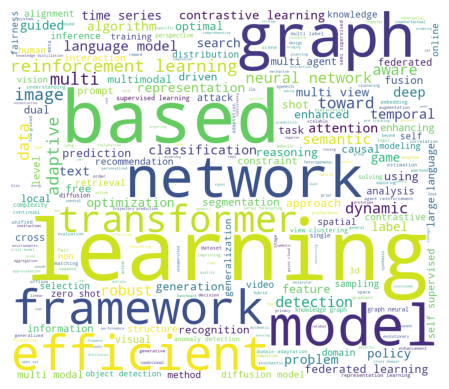

In [24]:
plt.imshow(wordcloud)
plt.axis("off")
plt.show()

In [25]:
wordcloud.to_file('wordcloud_ijcai2024_title.pdf')

In [26]:
from collections import Counter

In [27]:
wordcount = Counter([i.lower() for i in text_all.split(" ") if i.lower() not in stop_words_list])

In [28]:
wordcount

Counter({'learning': 187,
         'graph': 58,
         'detection': 48,
         'models': 46,
         'neural': 43,
         'network': 41,
         'reinforcement': 37,
         'efficient': 36,
         'framework': 34,
         'image': 34,
         'model': 32,
         'networks': 31,
         'contrastive': 31,
         'federated': 31,
         'language': 31,
         'towards': 28,
         'transformer': 27,
         'data': 26,
         'adaptive': 26,
         'robust': 26,
         'knowledge': 26,
         'prediction': 24,
         'time': 22,
         'representation': 22,
         'deep': 22,
         'classification': 21,
         'diffusion': 20,
         'dynamic': 20,
         'optimization': 19,
         'multi-view': 19,
         'domain': 19,
         'recognition': 18,
         'adaptation': 18,
         'series': 18,
         'using': 18,
         'generation': 17,
         'search': 17,
         'semantic': 17,
         'large': 17,
         'clustering':